In [1]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
train_identity = pd.read_csv("../data/train_identity.txt")
train_transaction = pd.read_csv("../data/train_transaction.txt")

train_df =  train_transaction.merge(train_identity , on="TransactionID" , how="left")

In [3]:
missing_vals = pd.DataFrame({
    'Missing_Count' : train_df.isnull().sum() , 
    'Missing_Percentage' : train_df.isnull().mean()*100
})

missing_vals  = missing_vals[missing_vals['Missing_Count'] > 0]
missing_vals = missing_vals.sort_values('Missing_Percentage' , ascending=False)
missing_vals

,Missing_Count,Missing_Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
...,...,...
V309,12,0.002032
V312,12,0.002032
V311,12,0.002032
V310,12,0.002032


In [4]:
missing_vals[(missing_vals['Missing_Percentage'] > 75) & (missing_vals['Missing_Percentage'] < 90)].index

Index(['D13', 'D14', 'D12', 'id_04', 'id_03', 'D6', 'id_33', 'id_10', 'D8',
       'id_09',
       ...
       'V220', 'V222', 'V238', 'V221', 'V227', 'V234', 'V245', 'V271', 'id_01',
       'id_12'],
      dtype='str', length=196)

In [5]:
print(" >90% missing = " , (missing_vals['Missing_Percentage'] > 90).sum())
print(" 75-90% missing = " , ((missing_vals['Missing_Percentage'] > 75) & (missing_vals['Missing_Percentage'] < 90)).sum())
print(" 50-75% missing = " , ((missing_vals['Missing_Percentage'] > 50) & (missing_vals['Missing_Percentage'] < 75)).sum())

 >90% missing =  12
 75-90% missing =  196
 50-75% missing =  6


In [16]:
missing_by_fraud = pd.DataFrame({
    "NonFraud_Missing_%" : train_df[train_df["isFraud"] == 0].isna().mean()*100 , 
    "Fraud_Missing_%" : train_df[train_df["isFraud"] == 1].isna().mean()*100

})
missing_by_fraud["Difference"] = (missing_by_fraud["Fraud_Missing_%"] - missing_by_fraud["NonFraud_Missing_%"])
missing_by_fraud.sort_values("Difference" , key=abs , ascending=True)
missing_by_fraud

,NonFraud_Missing_%,Fraud_Missing_%,Difference
TransactionID,0.000000,0.000000,0.000000
isFraud,0.000000,0.000000,0.000000
TransactionDT,0.000000,0.000000,0.000000
TransactionAmt,0.000000,0.000000,0.000000
ProductCD,0.000000,0.000000,0.000000
...,...,...,...
id_36,77.229648,45.690364,-31.539283
id_37,77.229648,45.690364,-31.539283
id_38,77.229648,45.690364,-31.539283
DeviceType,77.258426,45.743600,-31.514826


In [6]:
train_df["isFraud"].value_counts() , train_df["isFraud"].value_counts(normalize=True)*100

(isFraud
 0    569877
 1     20663
 Name: count, dtype: int64,
 isFraud
 0    96.500999
 1     3.499001
 Name: proportion, dtype: float64)

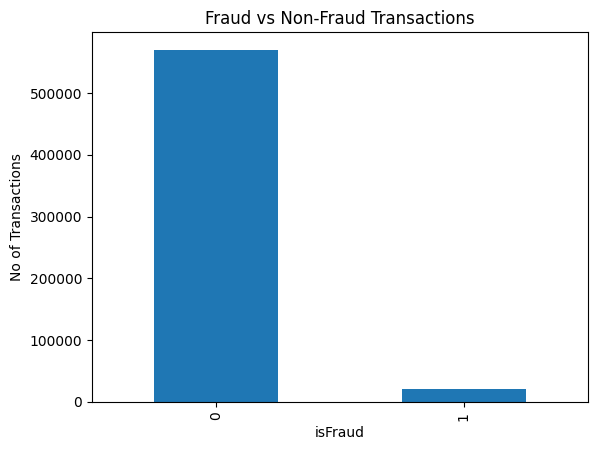

In [7]:
train_df["isFraud"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("No of Transactions")
plt.show()

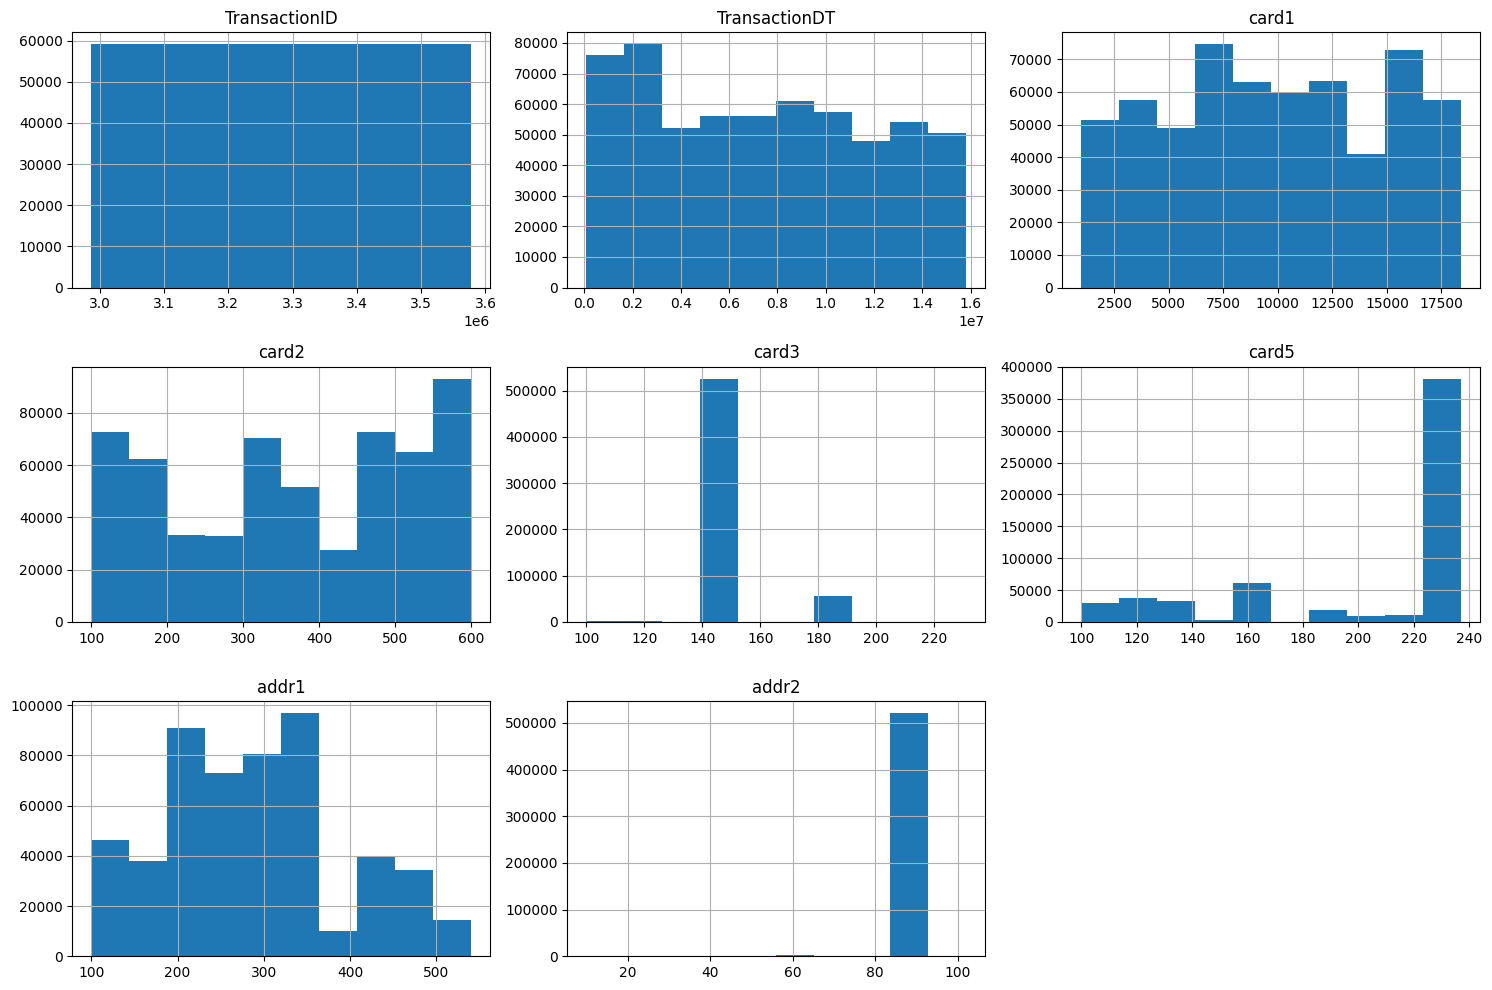

In [8]:
cols = ["TransactionID" , "TransactionDT" , "card1" , "card2" , "card3" , "card5" , "addr1" , "addr2"]
train_df[cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

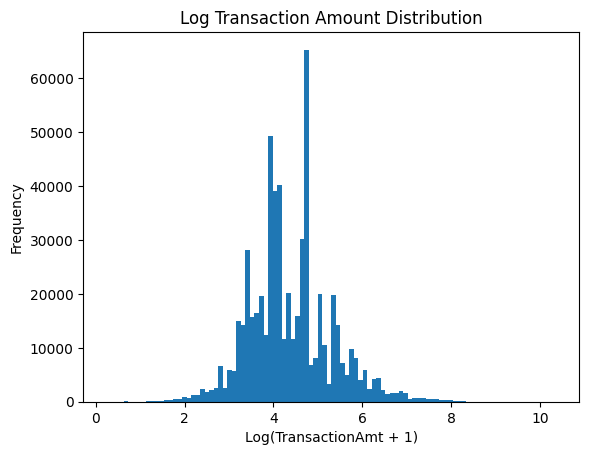

In [9]:
plt.hist(np.log1p(train_df["TransactionAmt"]) , bins=100)
plt.title("Log Transaction Amount Distribution")
plt.xlabel("Log(TransactionAmt + 1)")
plt.ylabel("Frequency")
plt.show()

In [10]:
# Fraud vs Transaction Amount

train_df.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [11]:
train_df.groupby("isFraud")["TransactionAmt"].mean()

isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

In [12]:
pd.crosstab(
    train_df["ProductCD"] , 
    train_df["isFraud"] ,
    normalize="index"
)*100

isFraud,0,1
ProductCD,,
C,88.312731,11.687269
H,95.233769,4.766231
R,96.217406,3.782594
S,94.100447,5.899553
W,97.960061,2.039939


In [13]:
pd.crosstab(
    train_df["card4"] , 
    train_df["isFraud"] ,
    normalize="index"
)*100

isFraud,0,1
card4,,
american express,97.130163,2.869837
discover,92.271839,7.728161
mastercard,96.566905,3.433095
visa,96.524390,3.475610


In [14]:
pd.crosstab(
    train_df["card6"] , 
    train_df["isFraud"] ,
    normalize="index"
)*100

isFraud,0,1
card6,,
charge card,100.000000,0.000000
credit,93.321520,6.678480
debit,97.573749,2.426251
debit or credit,100.000000,0.000000


In [15]:
pd.crosstab(
    train_df["DeviceType"] , 
    train_df["isFraud"] ,
    normalize="index"
)*100

isFraud,0,1
DeviceType,,
desktop,93.478542,6.521458
mobile,89.833768,10.166232
